In [7]:
import re
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split

Check if Cuda is Available


In [2]:
import torch

print(f'{torch.cuda.is_available() = }')
print(f'{torch.cuda.device_count() = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 2


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00a 0:00:01


In [4]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


Setting up the dataset paths

In [11]:
dataset_path = "/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations"

In [15]:
from pathlib import Path

dataset_path = Path("/kaggle/input/datasets/andrewmvd/car-plate-detection")
print("Dataset exists:", dataset_path.exists())
print("Images:", len(list((dataset_path / "images").glob("*.png"))))
print("XMLs:", len(list((dataset_path / "annotations").glob("*.xml"))))

Dataset exists: True
Images: 433
XMLs: 433


In [16]:
def the_number_in_the_string(filename):
    """
    Extracts the first sequence of digits from the given filename string and returns it as an integer.
    If no digits are found, returns 0.

    Parameters:
    filename (str): The input string to search for digits.

    Returns:
    int: The first sequence of digits found in the input string, or 0 if no digits are found.
    """
    # Search for the first occurrence of one or more digits in the filename
    match = re.search(r'(\d+)', filename)
    
    # If a match is found, return the matched number as an integer
    if match:
        return int(match.group(0))
    # If no match is found, return 0
    else:
        return 0

# Example usage
print(the_number_in_the_string("file123.txt"))  # Output: 123
print(the_number_in_the_string("no_numbers_here"))  # Output: 0

123
0


Formatting the XML File and creating DF

In [17]:
import os
import cv2
import pandas as pd
import xml.etree.ElementTree as xet
from glob import glob

# Initialize a dictionary to store labels and image information
labels_dict = dict(
    img_path=[], 
    xmin=[], 
    xmax=[], 
    ymin=[], 
    ymax=[], 
    img_w=[], 
    img_h=[]
)

# Get the list of XML files from the annotations directory
xml_files = glob(f'{dataset_path}/annotations/*.xml')

# Process each XML file, sorted by the numerical value in the filename
for filename in sorted(xml_files, key=the_number_in_the_string):
    # Parse the XML file
    info = xet.parse(filename)
    root = info.getroot()
    
    # Find the 'object' element in the XML and extract bounding box information
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)
    
    # Get the image filename and construct the full path to the image
    img_name = root.find('filename').text
    img_path = os.path.join(dataset_path, 'images', img_name)

    # Append the extracted information to the respective lists in the dictionary
    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)
    
    # Read the image to get its dimensions
    height, width, _ = cv2.imread(img_path).shape
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    
# Convert the dictionary to a pandas DataFrame
alldata = pd.DataFrame(labels_dict)

# Display the DataFrame
alldata

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


In [18]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
# Use 10% of the data for the test set
train, test = train_test_split(alldata, test_size=1/10, random_state=42)

# Split the training data further into training and validation sets
# Use 8/9 of the remaining data for the training set, resulting in an 80/10/10 split overall
train, val = train_test_split(train, train_size=8/9, random_state=42)

# Print the number of samples in each set
print(f'''
      len(train) = {len(train)}
      len(val) = {len(val)}
      len(test) = {len(test)}
''')



      len(train) = 345
      len(val) = 44
      len(test) = 44



In [19]:
import os
import shutil
import pandas as pd

# Remove the 'datasets' directory if it exists
if os.path.exists('datasets'):
    shutil.rmtree('datasets')

In [20]:
train

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
124,/kaggle/input/datasets/andrewmvd/car-plate-det...,305,320,256,267,400,267
315,/kaggle/input/datasets/andrewmvd/car-plate-det...,12,385,98,181,400,300
282,/kaggle/input/datasets/andrewmvd/car-plate-det...,37,319,145,203,350,263
236,/kaggle/input/datasets/andrewmvd/car-plate-det...,223,250,106,119,400,176
112,/kaggle/input/datasets/andrewmvd/car-plate-det...,49,164,135,191,240,400
...,...,...,...,...,...,...,...
110,/kaggle/input/datasets/andrewmvd/car-plate-det...,286,328,133,159,400,267
255,/kaggle/input/datasets/andrewmvd/car-plate-det...,116,273,156,188,400,267
292,/kaggle/input/datasets/andrewmvd/car-plate-det...,91,137,187,208,400,267
54,/kaggle/input/datasets/andrewmvd/car-plate-det...,148,257,61,118,400,300


In [21]:
def make_split_folder_in_yolo_format(split_name, split_df):
    """
    Creates a folder structure for a dataset split (train/val/test) in YOLO format.

    Parameters:
    split_name (str): The name of the split (e.g., 'train', 'val', 'test').
    split_df (pd.DataFrame): The DataFrame containing the data for the split.

    The function will create 'labels' and 'images' subdirectories under 'datasets/cars_license_plate/{split_name}',
    and save the corresponding labels and images in YOLO format.
    """
    labels_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'labels')
    images_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'images')

    # Create directories for labels and images
    os.makedirs(labels_path)
    os.makedirs(images_path)
    
    # Iterate over each row in the DataFrame
    for _, row in split_df.iterrows():
        img_name, img_extension = os.path.splitext(os.path.basename(row['img_path']))
        
        # Calculate YOLO format bounding box coordinates
        x_center = (row['xmin'] + row['xmax']) / 2 / row['img_w']
        y_center = (row['ymin'] + row['ymax']) / 2 / row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']

        # Save the label in YOLO format
        label_path = os.path.join(labels_path, f'{img_name}.txt')
        with open(label_path, 'w') as file:
            file.write(f"0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}\n")
            
        # Copy the image to the images directory
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))
    
    print(f"Created '{images_path}' and '{labels_path}'")

In [22]:
# Create YOLO format folders for train, validation, and test splits
make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)

Created 'datasets/cars_license_plate_new/train/images' and 'datasets/cars_license_plate_new/train/labels'
Created 'datasets/cars_license_plate_new/val/images' and 'datasets/cars_license_plate_new/val/labels'
Created 'datasets/cars_license_plate_new/test/images' and 'datasets/cars_license_plate_new/test/labels'


In [23]:
os.getcwd()

'/kaggle/working'

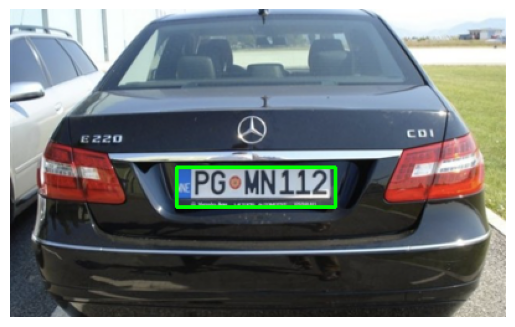

In [24]:
import os
import cv2
import matplotlib.pyplot as plt

# Directory paths
image_dir = 'datasets/cars_license_plate_new/train/images'
label_dir = 'datasets/cars_license_plate_new/train/labels'

# Get the first image file
image_files = sorted(os.listdir(image_dir))
first_image_file = image_files[0]

# Construct paths for the image and its corresponding label
image_path = os.path.join(image_dir, first_image_file)
label_path = os.path.join(label_dir, os.path.splitext(first_image_file)[0] + '.txt')

# Load the image using OpenCV
image = cv2.imread(image_path)
# Convert the image from BGR (OpenCV default) to RGB (matplotlib default)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Read the label file to get bounding box information
with open(label_path, 'r') as f:
    lines = f.readlines()

# Plot the bounding box on the image
for line in lines:
    # Parse the label file line to extract bounding box information
    class_id, x_center, y_center, width, height = map(float, line.strip().split())
    img_height, img_width, _ = image.shape

    # Convert YOLO format to bounding box format
    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    # Calculate the top-left and bottom-right coordinates of the bounding box
    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    # Draw the bounding box on the image using a green rectangle
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display the image with bounding box using matplotlib
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.show()  # Display the image

In [25]:
# Define the content of the datasets.yaml file
datasets_yaml = '''
path: cars_license_plate_new

train: train/images
val: val/images
test: test/images

# number of classes
nc: 1

# class names
names: ['license_plate']
'''

# Write the content to the datasets.yaml file
with open('datasets.yaml', 'w') as file:
    file.write(datasets_yaml)

In [26]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [29]:
from ultralytics import YOLO

# YOLOv8n
model_n = YOLO("yolov8n.pt")
results_n = model_n.train(
    data='datasets.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    workers=2,
    patience=15,
    pretrained=True,
    project="/kaggle/working/runs",
    name="yolov8n_plate",
    device=0
)

# YOLOv8s
model_s = YOLO("yolov8s.pt")
results_s = model_s.train(
    data='datasets.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    workers=2,
    patience=15,
    pretrained=True,
    project="/kaggle/working/runs",
    name="yolov8s_plate",
    device=0
)

# YOLOv8m
model_m = YOLO("yolov8m.pt")
results_m = model_m.train(
    data='datasets.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    workers=2,
    patience=15,
    pretrained=True,
    project="/kaggle/working/runs",
    name="yolov8m_plate",
    device=0
)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_plate2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspectiv

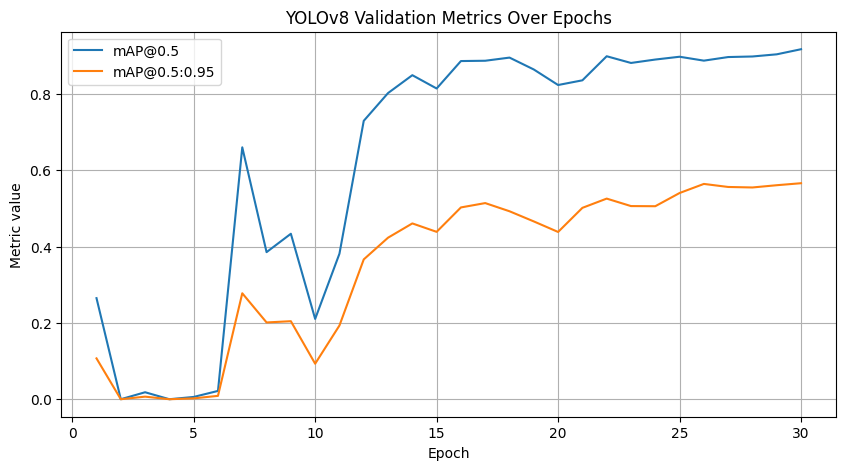

In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

# If you used a custom project folder, change this path accordingly
base_dir = Path("/kaggle/working/runs")

# Find the most recent results.csv from any YOLO run
result_files = list(base_dir.rglob("results.csv"))

if len(result_files) == 0:
    raise FileNotFoundError("No results.csv found under /kaggle/working/runs")

# Pick the latest modified results.csv
log_file = max(result_files, key=lambda p: p.stat().st_mtime)

# Load the training results
results = pd.read_csv(log_file)
results.columns = results.columns.str.strip()

# Epochs
epochs = results.index + 1

# Metrics
mAP_0_5 = results["metrics/mAP50(B)"]
mAP_0_5_0_95 = results["metrics/mAP50-95(B)"]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, mAP_0_5, label="mAP@0.5")
plt.plot(epochs, mAP_0_5_0_95, label="mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("YOLOv8 Validation Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
import pandas as pd

# Put your actual results objects here
models = {
    "Nano": results_n,
    "Small": results_s,
    "Medium": results_m
}

rows = []

for name, res in models.items():
    m = res.results_dict if hasattr(res, "results_dict") else {}
    
    # Ultralytics validation metrics names can vary slightly by version
    precision = m.get("metrics/precision(B)", None)
    recall = m.get("metrics/recall(B)", None)
    map50 = m.get("metrics/mAP50(B)", None)
    map5095 = m.get("metrics/mAP50-95(B)", None)

    rows.append({
        "YOLOv8 variants": name,
        "Params (M)": None,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "mAP50-95": map5095
    })

df = pd.DataFrame(rows)
df

,YOLOv8 variants,Params (M),Precision,Recall,mAP50,mAP50-95
0,Nano,None,0.974581,0.871499,0.942392,0.605662
1,Small,None,0.887194,0.863636,0.921576,0.568139
2,Medium,None,0.875731,0.818182,0.917598,0.566055


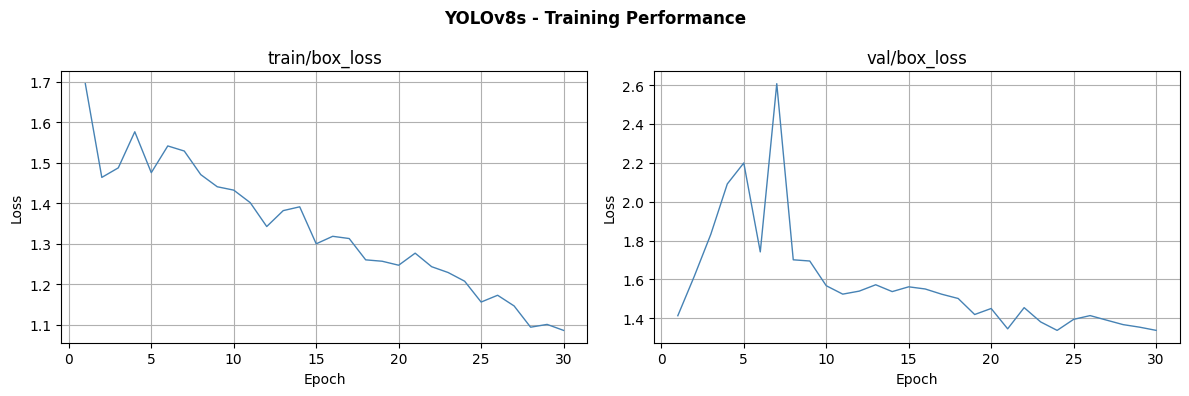

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# Correct path pattern based on your folder structure
log_dir = 'runs/yolov8s_plate'  # Change to whichever model you want to plot

# Load the training results
results = pd.read_csv(os.path.join(log_dir, 'results.csv'))
results.columns = results.columns.str.strip()

epochs = results.index + 1

train_box_loss = results['train/box_loss']
val_box_loss   = results['val/box_loss']

# Plot separately
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_box_loss, color='steelblue', linewidth=1)
axes[0].set_title('train/box_loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(epochs, val_box_loss, color='steelblue', linewidth=1)
axes[1].set_title('val/box_loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

plt.suptitle('YOLOv8s - Training Performance', fontweight='bold')
plt.tight_layout()
plt.show()

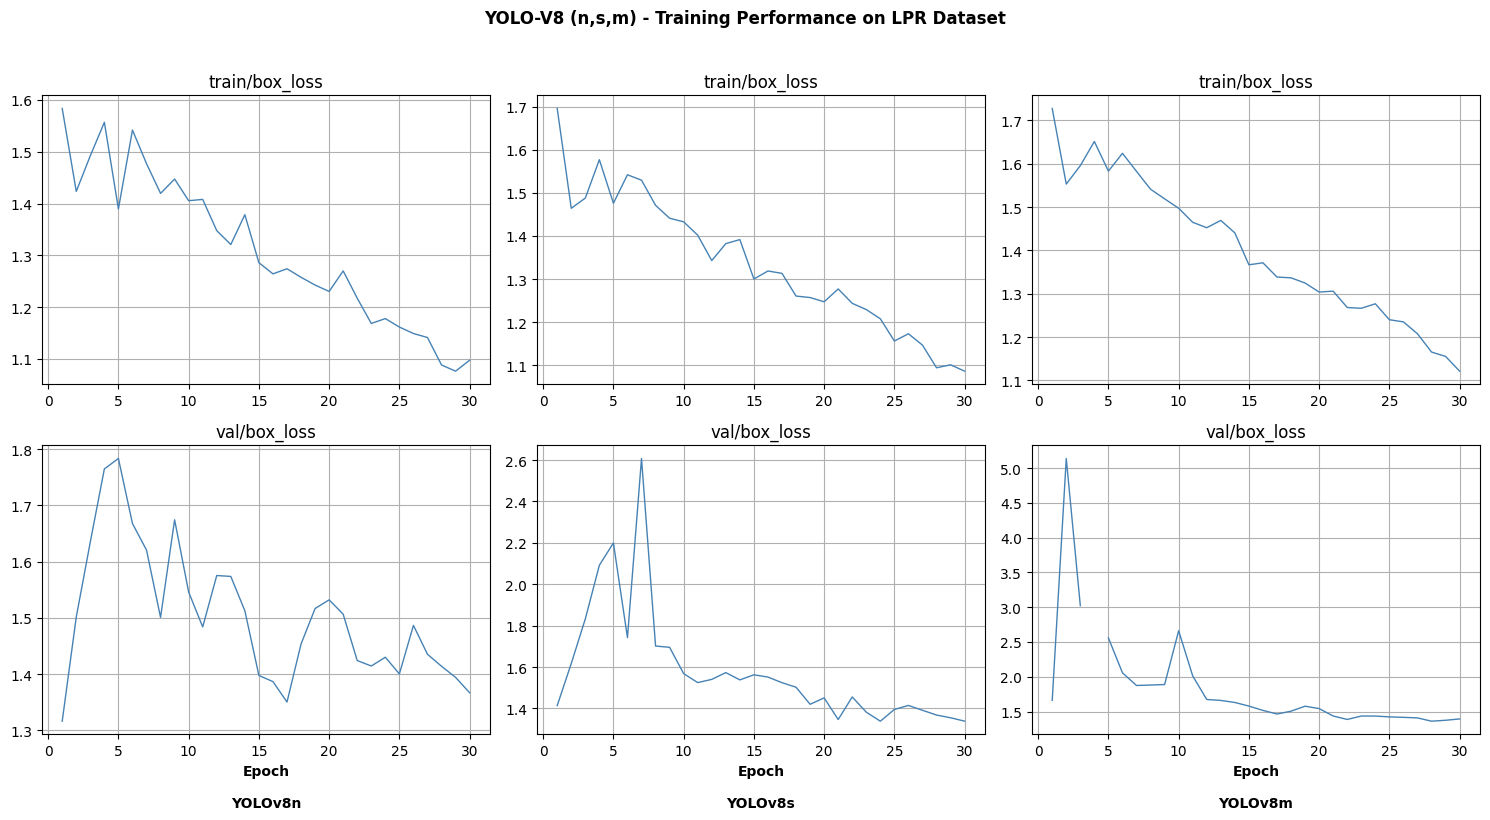

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Fixed paths — n uses 'plate2' folder
models = {
    'YOLOv8n': 'runs/yolov8n_plate2',  # ← plate2 has results.csv
    'YOLOv8s': 'runs/yolov8s_plate',
    'YOLOv8m': 'runs/yolov8m_plate',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (model_name, log_dir) in enumerate(models.items()):
    results = pd.read_csv(os.path.join(log_dir, 'results.csv'))
    results.columns = results.columns.str.strip()
    epochs = results.index + 1

    # Train box loss (top row)
    axes[0][col].plot(epochs, results['train/box_loss'], color='steelblue', linewidth=1)
    axes[0][col].set_title('train/box_loss')
    axes[0][col].grid(True)

    # Val box loss (bottom row)
    axes[1][col].plot(epochs, results['val/box_loss'], color='steelblue', linewidth=1)
    axes[1][col].set_title('val/box_loss')
    axes[1][col].grid(True)

    # Model name below each column
    axes[1][col].set_xlabel(f'Epoch\n\n{model_name}', fontweight='bold')

plt.suptitle('YOLO-V8 (n,s,m) - Training Performance on LPR Dataset', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

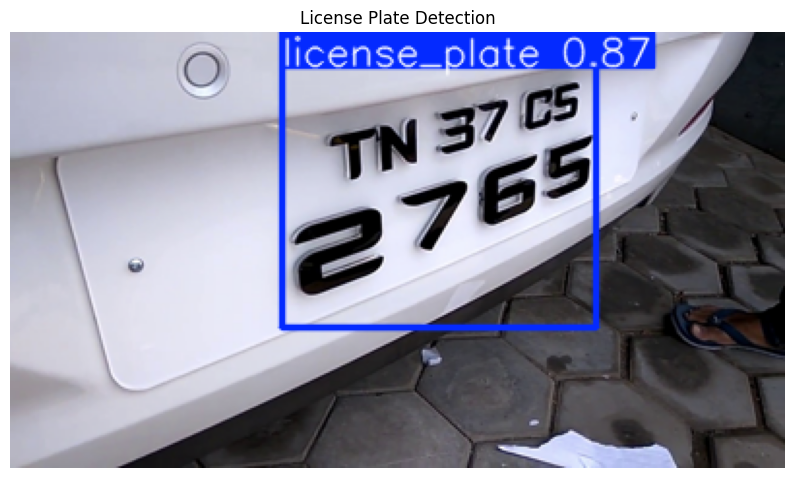

Box 1: confidence=0.870, coords=(140.9, 0.9, 302.6, 152.3)


In [47]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# choose the model you want
model_path = "/kaggle/working/runs/yolov8n_plate2/weights/best.pt"
# model_path = "/kaggle/working/runs/yolov8s_plate/weights/best.pt"
# model_path = "/kaggle/working/runs/yolov8m_plate/weights/best.pt"

# give any Kaggle image path here
image_path = "/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars10.png"

model = YOLO(model_path)

results = model.predict(source=image_path, conf=0.25, verbose=False)
r = results[0]

boxed = r.plot()

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("License Plate Detection")
plt.show()

if len(r.boxes) == 0:
    print("No plate detected.")
else:
    for i, box in enumerate(r.boxes):
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf[0])
        print(f"Box {i+1}: confidence={conf:.3f}, coords=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

Implementing Text Extraction

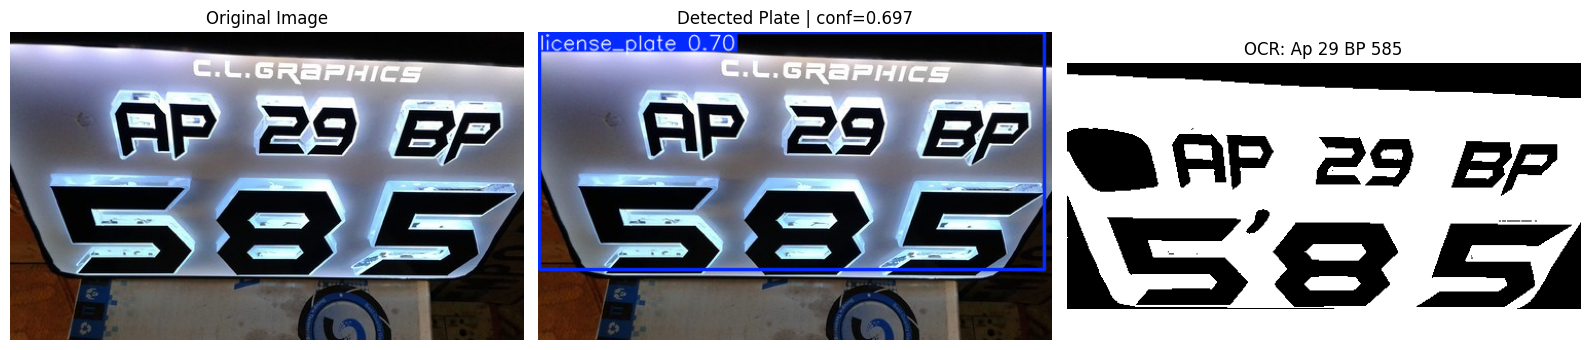

Detection confidence: 0.697
OCR text: Ap 29 BP 585


In [49]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
import easyocr

# paths
model_path = "/kaggle/working/runs/yolov8n_plate2/weights/best.pt"   # change if needed
image_path = "/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars131.png" 

# load model
model = YOLO(model_path)

# detect plate
results = model.predict(source=image_path, conf=0.25, verbose=False)
r = results[0]

# read image
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError("Image not found. Check image_path.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

if len(r.boxes) == 0:
    print("No license plate detected.")
else:
    # take the best box
    best_box = max(r.boxes, key=lambda b: float(b.conf[0]))
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].tolist())
    conf = float(best_box.conf[0])

    # crop plate with small padding
    pad = 8
    h, w = img.shape[:2]
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(w, x2 + pad)
    y2 = min(h, y2 + pad)

    crop = img[y1:y2, x1:x2]

    # preprocess for OCR
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 11, 17, 17)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    # OCR
    reader = easyocr.Reader(['en'], gpu=True)
    ocr_result = reader.readtext(thresh, detail=0, paragraph=False)

    plate_text = " ".join(ocr_result).strip()

    # display
    boxed = r.plot()
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Plate | conf={conf:.3f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(thresh, cmap="gray")
    plt.title(f"OCR: {plate_text if plate_text else 'No text found'}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Detection confidence: {conf:.3f}")
    print("OCR text:", plate_text if plate_text else "No text found")